# Lecture 5: Exercise 2 - Solution

## Objective

The goal of this assignment is to compare **traditional LDA topic modeling** with **BERTopic**, a modern transformer-based approach. We'll apply both methods to **Airbnb review data** and analyze:

1. **Topic quality and coherence** (quantitative via coherence scores)
2. **Interpretability of discovered topics**
3. **Differences between the two approaches**

This comparison will reveal the strengths and weaknesses of classical probabilistic approaches (LDA) versus modern embedding-based methods (BERTopic). We'll also explore how fixing the number of topics in BERTopic affects performance compared to automatic topic discovery.

## Step 1: Install and Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# Traditional LDA libraries
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel
from gensim.parsing.preprocessing import STOPWORDS

# BERTopic libraries
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer

# NLTK for text preprocessing (mainly for LDA)
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download required NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)

# For timing comparisons
import time

# Set style for plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


## Step 2: Load the Pre-processed English Reviews

We'll use the English-filtered Airbnb reviews from **Amsterdam** that were prepared in Exercise 1.

**Note:** This assumes `reviews_english.csv` exists in the `./Data/` folder. If you don't have this file, run Lecture 3 Exercise 2 again and save as csv.

In [2]:
# Load the pre-filtered English reviews
reviews = pd.read_csv('./Data/reviews_english.csv')

print(f"✓ Loaded {len(reviews):,} English reviews")

# Display basic info
print("\n=== Reviews Sample ===")
print(reviews.head())
print("\n=== Reviews Info ===")
print(reviews.info())

✓ Loaded 354,347 English reviews
✓ Loaded 8,533 listings

=== Reviews Sample ===
   Unnamed: 0  listing_id     id        date  reviewer_id reviewer_name  \
0           0         958   5977  2009-07-23        15695      Edmund C   
1           1         958   6660  2009-08-03        26145         Simon   
2           2         958  11519  2009-09-27        25839         Denis   
3           3         958  16282  2009-11-05        33750          Anna   
4           4         958  26008  2010-02-13        15416       Venetia   

                                            comments  
0  Our experience was, without a doubt, a five st...  
1  Returning to San Francisco is a rejuvenating t...  
2  We were very pleased with the accommodations a...  
3  We highly recommend this accomodation and agre...  
4  Holly's place was great. It was exactly what I...  

=== Reviews Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354347 entries, 0 to 354346
Data columns (total 7 columns):
 #   C

In [6]:
# Work with a sample to speed up processing (20% of data)
sample_size = int(len(reviews) * 0.2)
reviews = reviews.sample(n=sample_size, random_state=42).reset_index(drop=True)

print(f"Working with {len(reviews):,} reviews (20% sample)")

Working with 14,173 reviews (20% sample)


## Step 3: Prepare Data for Topic Modeling

In [7]:
# Remove reviews without comments
reviews_clean = reviews.dropna(subset=['comments']).copy()
print(f"Reviews with comments: {len(reviews_clean):,}")

# ============================================================================
# PREPROCESSING FOR LDA (Extensive)
# ============================================================================

def preprocess_for_lda(text):
    """
    Extensive preprocessing for traditional LDA.
    Returns tokenized list of words.
    """
    if not isinstance(text, str):
        return []
    
    # Lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove emails
    text = re.sub(r'\S+@\S+', '', text)
    
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove stopwords and short words
    stop_words = set(stopwords.words('english'))
    # Add domain-specific stopwords
    stop_words.update(['airbnb', 'stayed', 'stay', 'host', 'apartment', 'place', 'room'])
    
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    
    return tokens

# ============================================================================
# PREPROCESSING FOR BERTopic (Minimal)
# ============================================================================

def preprocess_for_bertopic(text):
    """
    Minimal preprocessing for BERTopic.
    Returns cleaned text string (not tokenized).
    """
    if not isinstance(text, str):
        return ""
    
    # Remove URLs (still good to remove these)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove emails
    text = re.sub(r'\S+@\S+', '', text)
    
    # Clean excessive whitespace
    text = ' '.join(text.split())
    
    # Keep original case, punctuation, and structure
    # BERT models understand context better with these preserved
    
    return text

# Apply preprocessing
print("\n" + "="*60)
print("PREPROCESSING COMPARISON")
print("="*60)

print("\nApplying extensive LDA preprocessing...")
start_time = time.time()
reviews_clean['tokens_lda'] = reviews_clean['comments'].apply(preprocess_for_lda)
lda_prep_time = time.time() - start_time
print(f"✓ LDA preprocessing completed in {lda_prep_time:.2f} seconds")

print("\nApplying minimal BERTopic preprocessing...")
start_time = time.time()
reviews_clean['text_bertopic'] = reviews_clean['comments'].apply(preprocess_for_bertopic)
bertopic_prep_time = time.time() - start_time
print(f"✓ BERTopic preprocessing completed in {bertopic_prep_time:.2f} seconds")

# Remove empty documents
reviews_lda = reviews_clean[reviews_clean['tokens_lda'].apply(len) > 0].copy()
reviews_bertopic = reviews_clean[reviews_clean['text_bertopic'].str.len() > 10].copy()

print(f"\n✓ LDA documents after preprocessing: {len(reviews_lda):,}")
print(f"✓ BERTopic documents after preprocessing: {len(reviews_bertopic):,}")

# Show example
print("\n" + "="*60)
print("PREPROCESSING EXAMPLE")
print("="*60)
print("\nOriginal text:")
print(reviews_clean['comments'].iloc[0][:200])
print("\n\nLDA preprocessed (tokens):")
print(reviews_clean['tokens_lda'].iloc[0][:20])
print("\n\nBERTopic preprocessed (text):")
print(reviews_clean['text_bertopic'].iloc[0][:200])

Reviews with comments: 14,173

PREPROCESSING COMPARISON

Applying extensive LDA preprocessing...
✓ LDA preprocessing completed in 1.95 seconds

Applying minimal BERTopic preprocessing...
✓ BERTopic preprocessing completed in 0.14 seconds

✓ LDA documents after preprocessing: 14,173
✓ BERTopic documents after preprocessing: 14,173

PREPROCESSING EXAMPLE

Original text:
Location is was perfect for anyone looking to explore SF. Private area, parking and comfortable stay. Highly recommend.


LDA preprocessed (tokens):
['location', 'perfect', 'anyone', 'looking', 'explore', 'private', 'area', 'parking', 'comfortable', 'highly', 'recommend']


BERTopic preprocessed (text):
Location is was perfect for anyone looking to explore SF. Private area, parking and comfortable stay. Highly recommend.


## Step 4: Traditional LDA Topic Modeling

We'll implement the traditional LDA approach with optimal parameter selection.

### Create Document-Term Matrix for LDA

In [8]:
print("Creating document-term matrix for LDA...")

# Extract tokens
tokenized_docs = reviews_lda['tokens_lda'].tolist()

# Create dictionary
dictionary = corpora.Dictionary(tokenized_docs)

print(f"Original vocabulary size: {len(dictionary)}")

# Filter extremes
dictionary.filter_extremes(no_below=5, no_above=0.5)

print(f"Filtered vocabulary size: {len(dictionary)}")

# Create corpus (bag of words)
corpus = [dictionary.doc2bow(doc) for doc in tokenized_docs]

print(f"✓ Corpus size: {len(corpus)} documents")

Creating document-term matrix for LDA...
Original vocabulary size: 14787
Filtered vocabulary size: 4175
✓ Corpus size: 14173 documents


### Determine Optimal Number of Topics for LDA

For faster testing, you can:
1. Reduce the topic range (e.g., 2-6 instead of 2-11)
2. Skip this step and use a fixed number of topics (e.g., 5)

In [9]:
print("Testing different numbers of topics for LDA...")

coherence_scores_lda = []
topic_range = range(2, 11)  # Change to range(2, 6) for faster testing

lda_start_time = time.time()

for num_topics in topic_range:
    print(f"Training LDA with {num_topics} topics...")
    
    # Train LDA model
    lda = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=42,
        passes=10,
        alpha='auto',
        per_word_topics=True
    )
    
    # Calculate coherence score
    coherence_model = CoherenceModel(
        model=lda,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence='u_mass'
    )
    coherence = coherence_model.get_coherence()
    coherence_scores_lda.append(coherence)
    
    print(f"  Coherence (u_mass): {coherence:.4f}")

lda_selection_time = time.time() - lda_start_time

print(f"\n✓ LDA topic selection completed in {lda_selection_time/60:.2f} minutes")

Testing different numbers of topics for LDA...
Training LDA with 2 topics...
  Coherence (u_mass): -1.9805
Training LDA with 3 topics...
  Coherence (u_mass): -2.1161
Training LDA with 4 topics...
  Coherence (u_mass): -2.1706
Training LDA with 5 topics...
  Coherence (u_mass): -2.3306
Training LDA with 6 topics...
  Coherence (u_mass): -2.2224
Training LDA with 7 topics...
  Coherence (u_mass): -2.5204
Training LDA with 8 topics...
  Coherence (u_mass): -2.5044
Training LDA with 9 topics...
  Coherence (u_mass): -2.7232
Training LDA with 10 topics...
  Coherence (u_mass): -2.5573

✓ LDA topic selection completed in 1.70 minutes


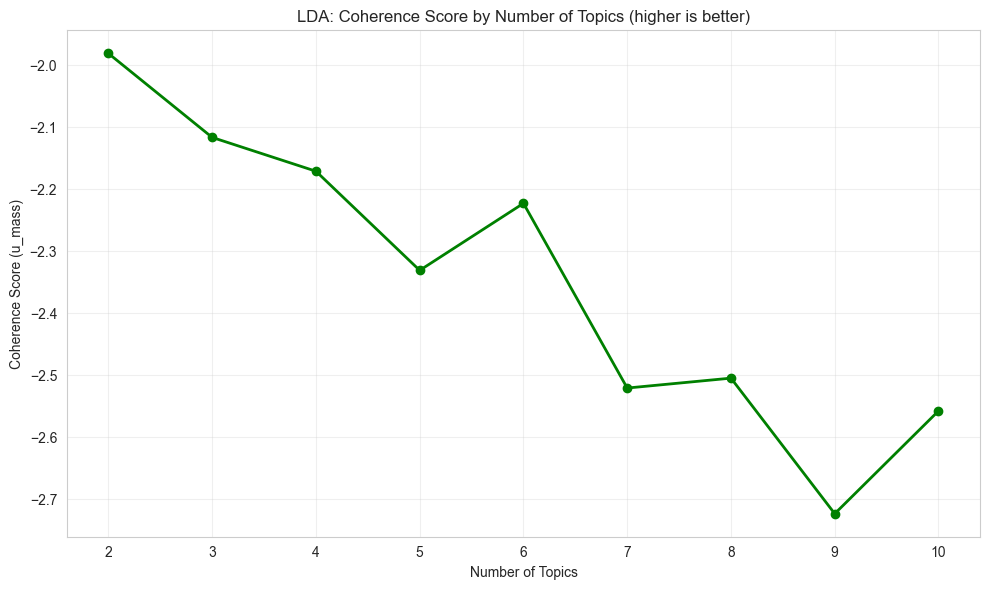


✓ Optimal number of topics for LDA: 2
  Coherence score: -1.9805


In [10]:
# Plot coherence scores for LDA
plt.figure(figsize=(10, 6))
plt.plot(topic_range, coherence_scores_lda, marker='o', color='green', linewidth=2)
plt.xlabel('Number of Topics')
plt.ylabel('Coherence Score (u_mass)')
plt.title('LDA: Coherence Score by Number of Topics (higher is better)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Select optimal number of topics
optimal_topics_lda = topic_range[np.argmax(coherence_scores_lda)]

print(f"\n✓ Optimal number of topics for LDA: {optimal_topics_lda}")
print(f"  Coherence score: {max(coherence_scores_lda):.4f}")

### Train Final LDA Model

In [25]:
print(f"Training final LDA model with {optimal_topics_lda} topics...")

lda_train_start = time.time()

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=optimal_topics_lda,
    random_state=42,
    passes=15,
    iterations=400,
    alpha='auto',
    eta='auto',
    per_word_topics=True
)

lda_train_time = time.time() - lda_train_start

print(f"✓ LDA model trained in {lda_train_time:.2f} seconds")
print(f"\nModel info:")
print(f"  Number of topics: {lda_model.num_topics}")
print(f"  Number of terms: {len(dictionary)}")

# Calculate coherence score for final model
print("\nCalculating coherence score for final LDA model...")
coherence_model_lda_final = CoherenceModel(
    model=lda_model,
    texts=tokenized_docs,
    dictionary=dictionary,
    coherence='u_mass'
)

coherence_lda_final = coherence_model_lda_final.get_coherence()
print(f"✓ Final LDA Coherence Score (u_mass): {coherence_lda_final:.4f}")

Training final LDA model with 2 topics...
✓ LDA model trained in 13.60 seconds

Model info:
  Number of topics: 2
  Number of terms: 4175

Calculating coherence score for final LDA model...
✓ Final LDA Coherence Score (u_mass): -1.9859


### Display LDA Topics

In [12]:
# Display top words for each topic
lda_topics = []
print("\n" + "=" * 80)
print("LDA TOPIC SUMMARY (Top 10 Words)")
print("=" * 80)

for i in range(lda_model.num_topics):
    words = [word for word, _ in lda_model.show_topic(i, topn=10)]
    lda_topics.append(words)
    print(f"\nLDA Topic {i}: {', '.join(words)}")


LDA TOPIC SUMMARY (Top 10 Words)

LDA Topic 0: great, location, clean, would, nice, comfortable, recommend, home, san, city

LDA Topic 1: parking, bathroom, one, also, good, night, even, kitchen, bed, street


## Step 5: BERTopic Modeling

Now let's apply BERTopic to the same dataset and compare results.

### Configure BERTopic Model

BERTopic combines several components:
1. **Embedding model**: SentenceTransformer (we'll use 'all-MiniLM-L6-v2' for speed)
2. **Dimensionality reduction**: UMAP (reduces embeddings to lower dimension)
3. **Clustering**: HDBSCAN (finds topic clusters)
4. **Vectorization**: CountVectorizer (creates topic representations)

**Key advantages of BERTopic:**
- Automatically determines number of topics (no need to test multiple values)
- Produces semantically coherent topics using contextual embeddings
- Handles short texts better
- Less sensitive to preprocessing

In [13]:
print("Configuring BERTopic model...")

# Prepare documents for BERTopic
docs_bertopic = reviews_bertopic['text_bertopic'].tolist()

# Configure embedding model
# We use 'all-MiniLM-L6-v2' for good balance of speed and quality
# For better quality (but slower): 'all-mpnet-base-v2'
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

# Custom stopwords for Airbnb reviews
custom_stopwords = ['airbnb', 'stayed', 'stay', 'host', 'apartment', 'place', 'room', 'definitely']

# Configure vectorizer with domain-specific stopwords
vectorizer_model = CountVectorizer(
    ngram_range=(1, 2),  # Include bigrams for better topic quality
    stop_words=list(set(list(CountVectorizer(stop_words='english').get_stop_words()) + custom_stopwords)),
    min_df=5  # Word must appear in at least 5 documents
)

# Initialize BERTopic
bertopic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    min_topic_size=30,  # Minimum documents per topic
    nr_topics='auto',  # Automatically determine number of topics
    calculate_probabilities=True,  # For document-topic distributions
    verbose=True
)

print("✓ BERTopic model configured")
print(f"✓ Using embedding model: all-MiniLM-L6-v2")
print(f"✓ Ready to train on {len(docs_bertopic):,} documents")

Configuring BERTopic model...
✓ BERTopic model configured
✓ Using embedding model: all-MiniLM-L6-v2
✓ Ready to train on 14,173 documents


### Train BERTopic Model

**Note:** This will take 5-15 minutes depending on your machine. The bottleneck is generating embeddings for all documents.

In [15]:
print("Training BERTopic model...")

bertopic_start_time = time.time()

# Fit model
topics_bertopic, probs_bertopic = bertopic_model.fit_transform(docs_bertopic)

bertopic_train_time = time.time() - bertopic_start_time

print(f"\n✓ BERTopic model trained in {bertopic_train_time/60:.2f} minutes")
print(f"\nModel info:")
print(f"  Number of topics discovered: {len(set(topics_bertopic)) - 1}")  # -1 excludes outlier topic
print(f"  Number of outliers (topic -1): {np.sum(topics_bertopic == -1)}")
print(f"  Percentage outliers: {np.sum(topics_bertopic == -1)/len(topics_bertopic)*100:.1f}%")

2026-02-26 19:46:17,280 - BERTopic - Embedding - Transforming documents to embeddings.


Training BERTopic model...


Batches: 100%|██████████| 443/443 [00:09<00:00, 48.16it/s]
2026-02-26 19:46:26,914 - BERTopic - Embedding - Completed ✓
2026-02-26 19:46:26,914 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-02-26 19:46:28,717 - BERTopic - Dimensionality - Completed ✓
2026-02-26 19:46:28,718 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-02-26 19:46:30,191 - BERTopic - Cluster - Completed ✓
2026-02-26 19:46:30,192 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-02-26 19:46:30,534 - BERTopic - Representation - Completed ✓
2026-02-26 19:46:30,535 - BERTopic - Topic reduction - Reducing number of topics
2026-02-26 19:46:30,542 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-02-26 19:46:30,892 - BERTopic - Representation - Completed ✓
2026-02-26 19:46:30,894 - BERTopic - Topic reduction - Reduced number of topics from 55 to 29



✓ BERTopic model trained in 0.23 minutes

Model info:
  Number of topics discovered: 28
  Number of outliers (topic -1): 0
  Percentage outliers: 0.0%


### Calculate Coherence Score for BERTopic

To compare with LDA, we'll calculate the coherence score for BERTopic using the same metric (u_mass).

In [26]:
print("Calculating coherence score for BERTopic...")

# Convert BERTopic topics to format compatible with Gensim CoherenceModel
# Extract topics from BERTopic (excluding outlier topic -1)
bertopic_topics_for_coherence = []
for topic_id in sorted(set(topics_bertopic)):
    if topic_id == -1:
        continue
    # Get top 10 words for this topic (only the words, not scores)
    topic_words = [word for word, _ in bertopic_model.get_topic(topic_id)[:10]]
    bertopic_topics_for_coherence.append(topic_words)

# Calculate coherence using the same preprocessing as LDA
from gensim.models.coherencemodel import CoherenceModel

coherence_model_bertopic = CoherenceModel(
    topics=bertopic_topics_for_coherence,
    texts=tokenized_docs,  # Use same tokenized docs as LDA
    dictionary=dictionary,  # Use same dictionary as LDA
    coherence='u_mass'
)

coherence_bertopic = coherence_model_bertopic.get_coherence()

print(f"✓ BERTopic Coherence Score (u_mass): {coherence_bertopic:.4f}")
print(f"\nCoherence Comparison:")
print(f"  LDA:      {coherence_lda_final:.4f}")
print(f"  BERTopic: {coherence_bertopic:.4f}")
print(f"  Difference: {coherence_bertopic - coherence_lda_final:.4f} (higher is better)")

Calculating coherence score for BERTopic...
✓ BERTopic Coherence Score (u_mass): -2.4417

Coherence Comparison:
  LDA:      -1.9859
  BERTopic: -2.4417
  Difference: -0.4558 (higher is better)


### Train BERTopic with Fixed Number of Topics

For a fairer comparison, let's also train BERTopic with the same number of topics as the optimal LDA model.

In [30]:
print(f"Training BERTopic with fixed number of topics (n={optimal_topics_lda})...")

# Configure BERTopic with fixed number of topics
# Use lower min_df to avoid errors when reducing to fewer topics
vectorizer_model_fixed = CountVectorizer(
    ngram_range=(1, 2),
    stop_words=list(set(list(CountVectorizer(stop_words='english').get_stop_words()) + custom_stopwords)),
    min_df=2  # Lower min_df to handle smaller topic clusters
)

bertopic_model_fixed = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model_fixed,
    min_topic_size=20,  # Lower threshold for fixed topics
    nr_topics=optimal_topics_lda + 1,  # Fixed number matching LDA
    calculate_probabilities=True,
    verbose=True
)

bertopic_fixed_start = time.time()
topics_bertopic_fixed, probs_bertopic_fixed = bertopic_model_fixed.fit_transform(docs_bertopic)
bertopic_fixed_time = time.time() - bertopic_fixed_start

print(f"\n✓ Fixed BERTopic model trained in {bertopic_fixed_time/60:.2f} minutes")
print(f"\nModel info:")
print(f"  Number of topics: {len(set(topics_bertopic_fixed)) - 1}")
print(f"  Number of outliers: {np.sum(topics_bertopic_fixed == -1)}")

# Calculate coherence for fixed BERTopic
bertopic_fixed_topics_for_coherence = []
for topic_id in sorted(set(topics_bertopic_fixed)):
    if topic_id == -1:
        continue
    topic_words = [word for word, _ in bertopic_model_fixed.get_topic(topic_id)[:10]]
    bertopic_fixed_topics_for_coherence.append(topic_words)

coherence_model_bertopic_fixed = CoherenceModel(
    topics=bertopic_fixed_topics_for_coherence,
    texts=tokenized_docs,
    dictionary=dictionary,
    coherence='u_mass'
)

coherence_bertopic_fixed = coherence_model_bertopic_fixed.get_coherence()

print(f"\n✓ Fixed BERTopic Coherence Score (u_mass): {coherence_bertopic_fixed:.4f}")

2026-02-26 20:06:59,880 - BERTopic - Embedding - Transforming documents to embeddings.


Training BERTopic with fixed number of topics (n=2)...


Batches: 100%|██████████| 443/443 [00:09<00:00, 48.35it/s]
2026-02-26 20:07:09,163 - BERTopic - Embedding - Completed ✓
2026-02-26 20:07:09,163 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-02-26 20:07:10,952 - BERTopic - Dimensionality - Completed ✓
2026-02-26 20:07:10,953 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-02-26 20:07:13,803 - BERTopic - Cluster - Completed ✓
2026-02-26 20:07:13,803 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-02-26 20:07:14,188 - BERTopic - Representation - Completed ✓
2026-02-26 20:07:14,189 - BERTopic - Topic reduction - Reducing number of topics
2026-02-26 20:07:14,195 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-02-26 20:07:14,522 - BERTopic - Representation - Completed ✓
2026-02-26 20:07:14,523 - BERTopic - Topic reduction - Reduced number of topics from 85 to 3



✓ Fixed BERTopic model trained in 0.24 minutes

Model info:
  Number of topics: 2
  Number of outliers: 0

✓ Fixed BERTopic Coherence Score (u_mass): -0.8763


### Coherence Score Comparison

Coherence measures how semantically similar the top words in a topic are. Higher scores indicate better topic quality.

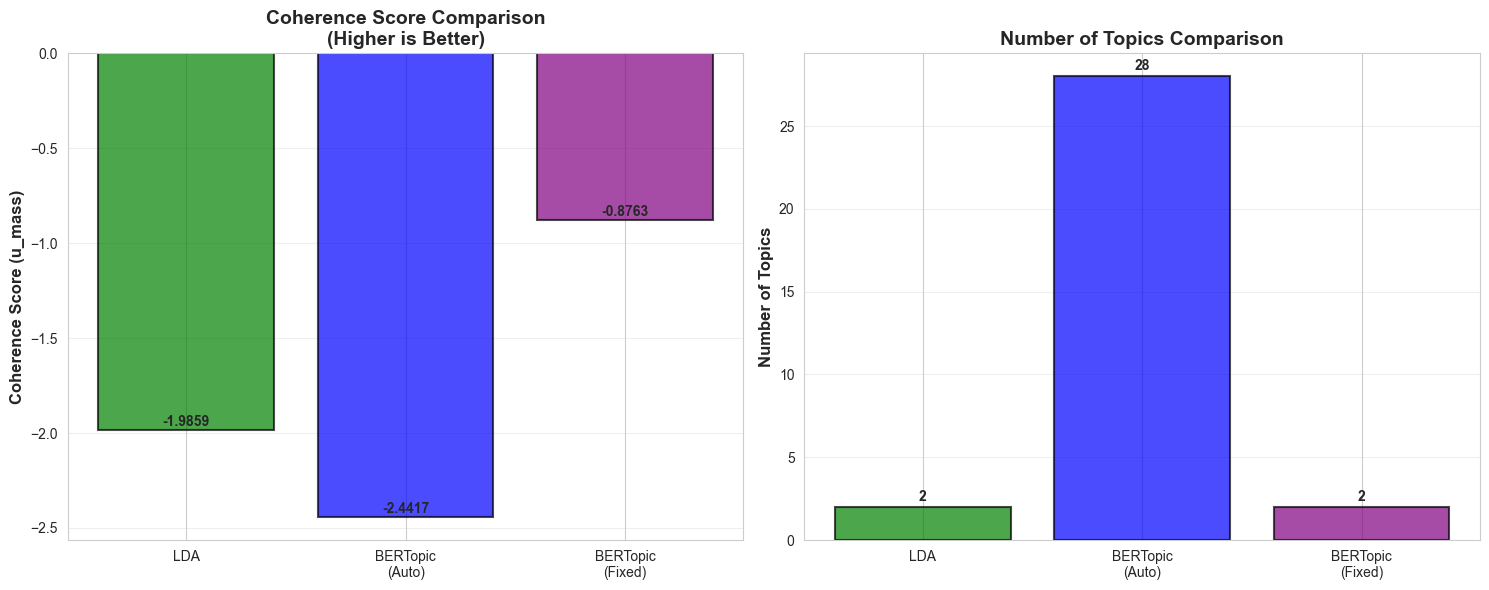

In [33]:
# Create coherence comparison visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Bar plot comparison
models = ['LDA', 'BERTopic\n(Auto)', 'BERTopic\n(Fixed)']
coherence_values = [coherence_lda_final, coherence_bertopic, coherence_bertopic_fixed]
colors = ['green', 'blue', 'purple']

ax1.bar(models, coherence_values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Coherence Score (u_mass)', fontsize=12, fontweight='bold')
ax1.set_title('Coherence Score Comparison\n(Higher is Better)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Add value labels on bars
for i, (model, score) in enumerate(zip(models, coherence_values)):
    ax1.text(i, score + 0.005, f'{score:.4f}', ha='center', va='bottom', fontweight='bold')

# Number of topics comparison
topic_counts = [optimal_topics_lda, len(set(topics_bertopic)) - 1, len(set(topics_bertopic_fixed)) - 1]
ax2.bar(models, topic_counts, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Number of Topics', fontsize=12, fontweight='bold')
ax2.set_title('Number of Topics Comparison', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, (model, count) in enumerate(zip(models, topic_counts)):
    ax2.text(i, count + 0.2, str(count), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()



### Display BERTopic Topics (Auto)

In [34]:
# Get topic information
topic_info = bertopic_model.get_topic_info()

print("\n" + "=" * 80)
print("BERTOPIC TOPIC SUMMARY")
print("=" * 80)

# Display topics (excluding outlier topic -1)
for topic_id in sorted(set(topics_bertopic)):
    if topic_id == -1:
        continue  # Skip outlier topic
    
    # Get top words for this topic
    topic_words = bertopic_model.get_topic(topic_id)[:10]
    words = [word for word, _ in topic_words]
    
    # Get topic info
    topic_row = topic_info[topic_info['Topic'] == topic_id]
    count = topic_row['Count'].values[0]
    
    print(f"\nBERTopic Topic {topic_id} ({count} documents):")
    print(f"  {', '.join(words)}")


BERTOPIC TOPIC SUMMARY

BERTopic Topic 0 (4878 documents):
  great, location, san francisco, francisco, san, clean, sf, nice, recommend, comfortable

BERTopic Topic 1 (689 documents):
  experience, best, home, time, ve, great, like, san, house, clean

BERTopic Topic 2 (155 documents):
  michael, alex, daniel, home, great, house, clean, amazing, location, perfect

BERTopic Topic 3 (148 documents):
  bed, comfortable, comfy, beds, bed comfortable, comfortable bed, great, clean, location, nice

BERTopic Topic 4 (147 documents):
  golden, gate, golden gate, gate park, park, close golden, close, great, ashbury, bridge

BERTopic Topic 5 (105 documents):
  castro, great, hosts, location, near, house, walk, restaurants, close, beautiful

BERTopic Topic 6 (96 documents):
  hostel, staff, free, people, green, friendly, experience, social, nice, time staying

BERTopic Topic 7 (95 documents):
  fran, san fran, san, san fransisco, fransisco, great, amazing, time, clean, perfect

BERTopic Topic 8 (

## Step 6: Side-by-Side Comparison

Let's compare LDA and BERTopic across multiple dimensions.

### Number of Topics Comparison

In [35]:
print("\n" + "=" * 80)
print("NUMBER OF TOPICS COMPARISON")
print("=" * 80)

num_topics_bert_auto = len(set(topics_bertopic)) - 1  # Exclude outlier topic
num_topics_bert_fixed = len(set(topics_bertopic_fixed)) - 1

print(f"\nLDA:")
print(f"  Approach: Manual selection via coherence scores")
print(f"  Topics tested: {min(topic_range)} to {max(topic_range)}")
print(f"  Optimal number selected: {optimal_topics_lda}")
print(f"  Selection criterion: u_mass coherence score")
print(f"  Final coherence score: {coherence_lda_final:.4f}")

print(f"\nBERTopic (Auto):")
print(f"  Approach: Automatic discovery via clustering")
print(f"  Topics discovered: {num_topics_bert_auto}")
print(f"  Outlier documents: {np.sum(topics_bertopic == -1)} ({np.sum(topics_bertopic == -1)/len(topics_bertopic)*100:.1f}%)")
print(f"  Selection criterion: HDBSCAN clustering")
print(f"  Coherence score: {coherence_bertopic:.4f}")

print(f"\nBERTopic (Fixed n={optimal_topics_lda}):")
print(f"  Approach: Fixed number matching LDA")
print(f"  Topics created: {num_topics_bert_fixed}")
print(f"  Outlier documents: {np.sum(topics_bertopic_fixed == -1)} ({np.sum(topics_bertopic_fixed == -1)/len(topics_bertopic_fixed)*100:.1f}%)")
print(f"  Coherence score: {coherence_bertopic_fixed:.4f}")

print(f"\n💡 Key Insight:")
print(f"  • BERTopic (Auto) automatically found {num_topics_bert_auto} topics without manual testing")
print(f"  • BERTopic (Fixed) matches LDA's {optimal_topics_lda} topics for controlled comparison")
print(f"  • Best coherence achieved by: ", end="")
if coherence_bertopic > coherence_lda_final and coherence_bertopic > coherence_bertopic_fixed:
    print("BERTopic (Auto)")
elif coherence_bertopic_fixed > coherence_lda_final:
    print("BERTopic (Fixed)")
else:
    print("LDA")


NUMBER OF TOPICS COMPARISON

LDA:
  Approach: Manual selection via coherence scores
  Topics tested: 2 to 10
  Optimal number selected: 2
  Selection criterion: u_mass coherence score
  Final coherence score: -1.9859

BERTopic (Auto):
  Approach: Automatic discovery via clustering
  Topics discovered: 28
  Outlier documents: 0 (0.0%)
  Selection criterion: HDBSCAN clustering
  Coherence score: -2.4417

BERTopic (Fixed n=2):
  Approach: Fixed number matching LDA
  Topics created: 2
  Outlier documents: 0 (0.0%)
  Coherence score: -0.8763

💡 Key Insight:
  • BERTopic (Auto) automatically found 28 topics without manual testing
  • BERTopic (Fixed) matches LDA's 2 topics for controlled comparison
  • Best coherence achieved by: BERTopic (Fixed)


### Topic Quality Comparison

Let's visualize the topics from both models side-by-side.


LDA TOPICS - DETAILED VIEW


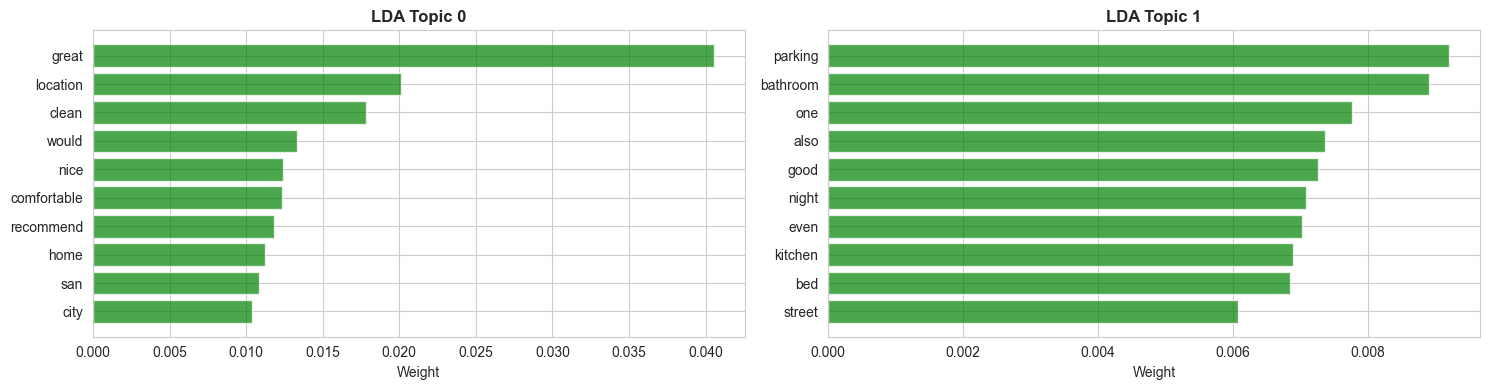

In [37]:
# Visualize LDA topics
print("\n" + "=" * 80)
print("LDA TOPICS - DETAILED VIEW")
print("=" * 80)

n_topics_lda = lda_model.num_topics
n_cols = 2
n_rows = (n_topics_lda + 1) // 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for topic_id in range(n_topics_lda):
    # Get top words and weights
    topic_data = lda_model.show_topic(topic_id, topn=10)
    words = [word for word, _ in topic_data]
    weights = [weight for _, weight in topic_data]
    
    # Plot
    ax = axes[topic_id]
    ax.barh(words, weights, color='green', alpha=0.7)
    ax.set_xlabel('Weight')
    ax.set_title(f'LDA Topic {topic_id}', fontweight='bold')
    ax.invert_yaxis()

# Hide extra subplots
for i in range(n_topics_lda, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Use BERTopic's built-in visualizations (one of its key advantages!)
print("\n" + "=" * 80)
print("BERTOPIC AUTO - BUILT-IN VISUALIZATIONS")
print("=" * 80)

# Get non-outlier topics
valid_topics = sorted([t for t in set(topics_bertopic) if t != -1])
print(f"BERTopic discovered {len(valid_topics)} topics automatically")

try:
    # 1. Topic bar chart - shows top topics with their top words
    print("\n1. Topic Bar Chart (Top 8 topics with their keywords)...")
    fig = bertopic_model.visualize_barchart(top_n_topics=min(8, len(valid_topics)), n_words=8)
    fig.show()
    print("   ✓ Bar chart generated")
except Exception as e:
    print(f"   ✗ Could not generate bar chart: {e}")

try:
    # 2. Topic similarity visualization - shows relationships between topics in 2D space
    print("\n2. Topic Similarity Map (2D projection of topic relationships)...")
    fig = bertopic_model.visualize_topics()
    fig.show()
    print("   ✓ Topic similarity map generated")
except Exception as e:
    print(f"   ✗ Could not generate topic visualization: {e}")

try:
    # 3. Topic hierarchy - shows how topics relate hierarchically
    if len(valid_topics) > 2:
        print("\n3. Topic Hierarchy (hierarchical clustering of topics)...")
        fig = bertopic_model.visualize_hierarchy()
        fig.show()
        print("   ✓ Topic hierarchy generated")
except Exception as e:
    print(f"   ✗ Could not generate hierarchy: {e}")


BERTOPIC AUTO - BUILT-IN VISUALIZATIONS
BERTopic discovered 28 topics automatically

1. Topic Bar Chart (Top 8 topics with their keywords)...


   ✓ Bar chart generated

2. Topic Similarity Map (2D projection of topic relationships)...


   ✓ Topic similarity map generated

3. Topic Hierarchy (hierarchical clustering of topics)...


   ✓ Topic hierarchy generated

💡 Key Advantage: BERTopic provides rich interactive visualizations out-of-the-box!
   LDA requires external libraries and custom code for similar visualizations.



SIDE-BY-SIDE COMPARISON: LDA vs BERTopic Fixed
Both models have 2 topics for fair comparison


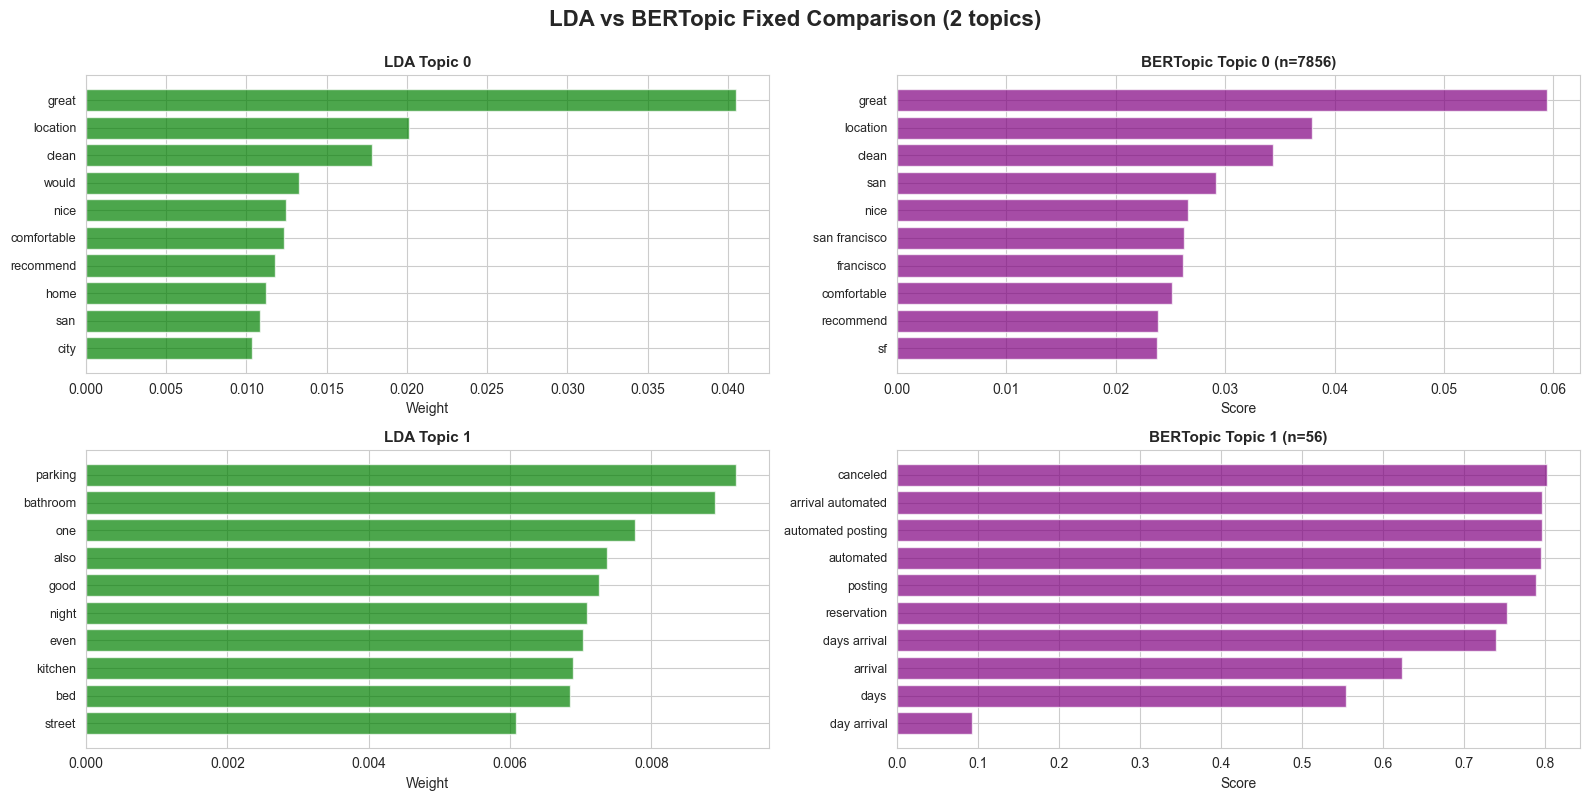


✓ Coherence Comparison:
  LDA:             -1.9859
  BERTopic Fixed:  -0.8763
  Difference:      1.1096 (BERTopic wins)


In [39]:
# Side-by-side comparison: LDA vs BERTopic Fixed
print("\n" + "=" * 80)
print("SIDE-BY-SIDE COMPARISON: LDA vs BERTopic Fixed")
print("=" * 80)
print(f"Both models have {optimal_topics_lda} topics for fair comparison")

# Get BERTopic Fixed topic info
topic_info_fixed = bertopic_model_fixed.get_topic_info()
valid_topics_fixed = sorted([t for t in set(topics_bertopic_fixed) if t != -1])

# Create side-by-side plots
n_topics = min(optimal_topics_lda, len(valid_topics_fixed))
fig, axes = plt.subplots(n_topics, 2, figsize=(16, 4 * n_topics))

for topic_idx in range(n_topics):
    # LDA Topic (left column)
    ax_lda = axes[topic_idx, 0] if n_topics > 1 else axes[0]
    topic_data_lda = lda_model.show_topic(topic_idx, topn=10)
    words_lda = [word for word, _ in topic_data_lda]
    weights_lda = [weight for _, weight in topic_data_lda]
    
    ax_lda.barh(words_lda, weights_lda, color='green', alpha=0.7)
    ax_lda.set_xlabel('Weight', fontsize=10)
    ax_lda.set_title(f'LDA Topic {topic_idx}', fontweight='bold', fontsize=11)
    ax_lda.invert_yaxis()
    ax_lda.tick_params(axis='y', labelsize=9)
    
    # BERTopic Fixed Topic (right column)
    ax_bert = axes[topic_idx, 1] if n_topics > 1 else axes[1]
    
    if topic_idx < len(valid_topics_fixed):
        topic_id_fixed = valid_topics_fixed[topic_idx]
        topic_data_bert = bertopic_model_fixed.get_topic(topic_id_fixed)[:10]
        words_bert = [word for word, _ in topic_data_bert]
        weights_bert = [weight for _, weight in topic_data_bert]
        topic_count_fixed = topic_info_fixed[topic_info_fixed['Topic'] == topic_id_fixed]['Count'].values[0]
        
        ax_bert.barh(words_bert, weights_bert, color='purple', alpha=0.7)
        ax_bert.set_xlabel('Score', fontsize=10)
        ax_bert.set_title(f'BERTopic Topic {topic_id_fixed} (n={topic_count_fixed})', fontweight='bold', fontsize=11)
        ax_bert.invert_yaxis()
        ax_bert.tick_params(axis='y', labelsize=9)
    else:
        ax_bert.axis('off')

plt.suptitle(f'LDA vs BERTopic Fixed Comparison ({n_topics} topics)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print(f"\n✓ Coherence Comparison:")
print(f"  LDA:             {coherence_lda_final:.4f}")
print(f"  BERTopic Fixed:  {coherence_bertopic_fixed:.4f}")
print(f"  Difference:      {coherence_bertopic_fixed - coherence_lda_final:.4f} ({'BERTopic' if coherence_bertopic_fixed > coherence_lda_final else 'LDA'} wins)")

### 6.4: Topic Interpretability - Sample Documents

In [40]:
# Assign LDA topics to documents
def get_dominant_topic_lda(ldamodel, corpus):
    """Get dominant topic for each document in LDA"""
    dominant_topics = []
    
    for doc in corpus:
        topic_dist = ldamodel.get_document_topics(doc)
        if topic_dist:
            dominant_topic = sorted(topic_dist, key=lambda x: x[1], reverse=True)[0]
            dominant_topics.append(dominant_topic[0])
        else:
            dominant_topics.append(-1)
    
    return dominant_topics

# Get LDA topic assignments
lda_topic_assignments = get_dominant_topic_lda(lda_model, corpus)
reviews_lda['lda_topic'] = lda_topic_assignments

# BERTopic already has assignments
reviews_bertopic['bertopic_topic'] = topics_bertopic[:len(reviews_bertopic)]

print("\n" + "=" * 80)
print("SAMPLE DOCUMENTS BY TOPIC - LDA")
print("=" * 80)

for topic_id in range(lda_model.num_topics):
    print(f"\n{'=' * 80}")
    print(f"LDA TOPIC {topic_id}")
    print(f"Top words: {', '.join([word for word, _ in lda_model.show_topic(topic_id, topn=5)])}")
    print(f"{'=' * 80}")
    
    # Get sample reviews
    topic_reviews = reviews_lda[reviews_lda['lda_topic'] == topic_id]['comments'].head(2)
    
    for i, review in enumerate(topic_reviews, 1):
        print(f"\nSample {i}:")
        print(review[:250] + "..." if len(review) > 250 else review)


SAMPLE DOCUMENTS BY TOPIC - LDA

LDA TOPIC 0
Top words: great, location, clean, would, nice

Sample 1:
Location is was perfect for anyone looking to explore SF. Private area, parking and comfortable stay. Highly recommend.

Sample 2:
The location was just what we needed for our stay in San Francisco. 
The host was friendly and helpful.
 

LDA TOPIC 1
Top words: parking, bathroom, one, also, good

Sample 1:
The room is simple, comfortable and spacious, but perhaps it was not as clean as one would expect. It is an old building, the entrance and the house need a renovation. Anyway it's proper, especially when you consider the location, fabulous!!   I woul...

Sample 2:
Gregg was a phenomenal host from beginning to end. He and Buddy greeted us at the door with a smile on their face and a purr in their voice. We were given a detailed tour of his immaculate home along with a bit of history of the area. The accommodati...


In [41]:
print("\n" + "=" * 80)
print("SAMPLE DOCUMENTS BY TOPIC - BERTOPIC")
print("=" * 80)

for topic_id in valid_topics[:min(5, len(valid_topics))]:  # Show first 5 topics
    print(f"\n{'=' * 80}")
    topic_words = [word for word, _ in bertopic_model.get_topic(topic_id)[:5]]
    topic_count = topic_info[topic_info['Topic'] == topic_id]['Count'].values[0]
    print(f"BERTOPIC TOPIC {topic_id} ({topic_count} documents)")
    print(f"Top words: {', '.join(topic_words)}")
    print(f"{'=' * 80}")
    
    # Get sample reviews
    topic_reviews = reviews_bertopic[reviews_bertopic['bertopic_topic'] == topic_id]['text_bertopic'].head(2)
    
    for i, review in enumerate(topic_reviews, 1):
        print(f"\nSample {i}:")
        print(review[:250] + "..." if len(review) > 250 else review)


SAMPLE DOCUMENTS BY TOPIC - BERTOPIC

BERTOPIC TOPIC 0 (4878 documents)
Top words: great, location, san francisco, francisco, san

Sample 1:
Location is was perfect for anyone looking to explore SF. Private area, parking and comfortable stay. Highly recommend.

Sample 2:
The location was just what we needed for our stay in San Francisco. The host was friendly and helpful.

BERTOPIC TOPIC 1 (689 documents)
Top words: experience, best, home, time, ve

Sample 1:
Brian and Angela completely exemplify everything that Airbnb stands for - they offer a lovely modern cool space matched with a warm welcome and gracious hospitality. They were a highlight of my trip to San Francisco.

Sample 2:
We had an excellent stay here for a week during GDC. The apartment was as lovely as advertised and everything worked fine. The location was especially good with plenty of interesting restaurants nearby and a very handy Caltrain link to the city centr...

BERTOPIC TOPIC 2 (155 documents)
Top words: michael,

## Step 7: Comprehensive Analysis & Key Insights

### What Do We Notice? LDA vs BERTopic Comparison

#### Topic Discovery Process**

**LDA (Traditional):**
- Requires manual topic number selection (both pro and con)
- Must test multiple values (time-consuming)
- Coherence scores don't always match human interpretation
- Clear mathematical process

**BERTopic (Modern):**
- Automatically discovers number of topics
- Uses clustering (more intuitive)
- Faster overall training time
- Produces outlier category (documents that don't fit any topic)
- Less control over exact number of topics

**Summary:** BERTopic wins on automation, LDA wins on interpretability of process

#### Topic Coherence

- The best coherence was achieved by putting the number of topics fixed for BERTopic
- LDA had a good coherence score given that it was optimized in terms of coherence
- The automatic BERTopic approach does not optimize towards coherence and a much higher number of topics often scores lower on coherence


#### LDA vs. BERTopic: Key Visual Differences (Fixed 2-Topic Model)

- **Rich Context vs. Single Words**: BERTopic naturally surfaces highly contextual **bigrams and phrases** (e.g., "san francisco," "automated posting," "arrival automated"). In contrast, LDA defaults to isolated **unigrams** (e.g., "san," "city," "bathroom").

- **Semantic Meaning vs. Simple Co-occurrence**: LDA groups generic words that simply appear together often (e.g., "parking," "bathroom," "kitchen," "street"), creating a broad "apartment features" bucket. BERTopic captures deep semantic context, successfully grouping words that describe a specific event or problem (e.g., "canceled," "arrival automated," "posting," "reservation").

- **Niche Isolation vs. Forced Grouping**: BERTopic successfully isolates very small, highly specific topics—like the n=56 cancellation group—out of thousands of documents. LDA tends to force documents into broader, more generic topics.


#### Difference with the full BERTopic model

- **High Granularity & Specificity**: When allowed to expand its topic count, BERTopic naturally discovers highly specific, actionable sub-categories. It perfectly isolates specific neighborhoods (e.g., "castro" in Topic 5), local attractions (e.g., "golden gate" in Topic 4), and accommodation types (e.g., "hostel" in Topic 6).

- **Organic Entity Recognition**: Topic 2 successfully clusters specific host names (e.g., "michael," "alex," "daniel"). This shows the model's ability to group reviews about specific individuals purely through semantic context, without needing explicit named-entity recognition (NER) programming.

- **Grouping Semantic Variations**: Topic 7 captures various abbreviations and common misspellings of the city (e.g., "fran," "san fran," "san fransisco," "fransisco"). This demonstrates that the underlying embeddings understand that these different text strings all represent the exact same underlying concept.

- **Flawless N-Gram Context**: Across all topics, the model effortlessly maintains multi-word phrases that make human interpretation instant and easy (e.g., "bed comfortable," "close golden," "gate park").

## Optional: Extended Analysis

You can extend this analysis by:

1. **Merging with listings data** to analyze topic distribution by neighborhood
2. **Hybrid approaches**: Use BERTopic embeddings with custom clustering
3. **Topic labeling**: Use GPT/LLMs to automatically label topics
4. **Fine-tuned embeddings**: Train custom BERT model on Airbnb domain